This document presents the EDA analysis of a dataset based on Twitch's top streamers. The code below tests libraries and checks if the dataset load properly.

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TwitchData = pd.read_csv("twitchdata-update.csv")
TwitchData = TwitchData.set_index("Channel") #sets the index to the channel's name
#check first parts of our dataset.
TwitchData.head()

,Watch time(Minutes),Stream time(minutes),Peak viewers,Average viewers,Followers,Followers gained,Views gained,Partnered,Mature,Language
Channel,,,,,,,,,,
xQcOW,6196161750,215250,222720,27716,3246298,1734810,93036735,True,False,English
summit1g,6091677300,211845,310998,25610,5310163,1370184,89705964,True,False,English
Gaules,5644590915,515280,387315,10976,1767635,1023779,102611607,True,True,Portuguese
ESL_CSGO,3970318140,517740,300575,7714,3944850,703986,106546942,True,False,English
Tfue,3671000070,123660,285644,29602,8938903,2068424,78998587,True,False,English


Once Our file is properly read and uploaded we check for the details like any missing informations:

In [88]:
TwitchData.shape
TwitchData.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, xQcOW to Remx
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Watch time(Minutes)   1000 non-null   int64 
 1   Stream time(minutes)  1000 non-null   int64 
 2   Peak viewers          1000 non-null   int64 
 3   Average viewers       1000 non-null   int64 
 4   Followers             1000 non-null   int64 
 5   Followers gained      1000 non-null   int64 
 6   Views gained          1000 non-null   int64 
 7   Partnered             1000 non-null   bool  
 8   Mature                1000 non-null   bool  
 9   Language              1000 non-null   object
dtypes: bool(2), int64(7), object(1)
memory usage: 104.6+ KB


With the information above we can see that:
*this dataset is formed by 1000 rows and 10 columns from which 7 are numerical variables, and 3 categorigal. (originally 4 but Channel was transformed into index)
*this dataset has no missing values, all rows present values in all of the 11 columns (one of them being the name of each streamer)

Now that we checked for missing values, finding none of them, now we an create graphs for each category as shown below:

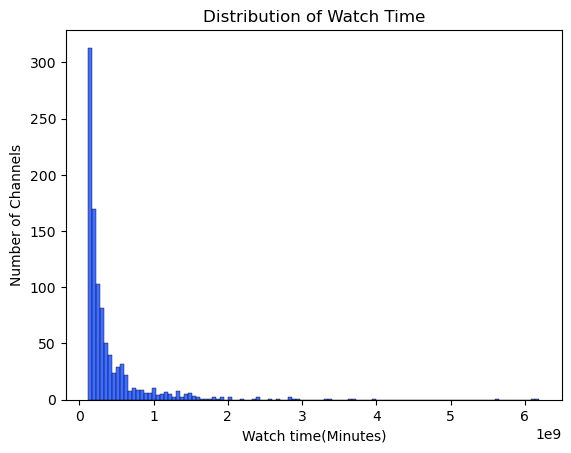

In [60]:
#Distributaion of Watchtime (time all viewers spent in watching a channel) in minutes and scientific notation to handle big numbers.

sns.histplot(data=TwitchData, x="Watch time(Minutes)")
plt.title("Distribution of Watch Time")
plt.ylabel("Number of Channels")

plt.show()

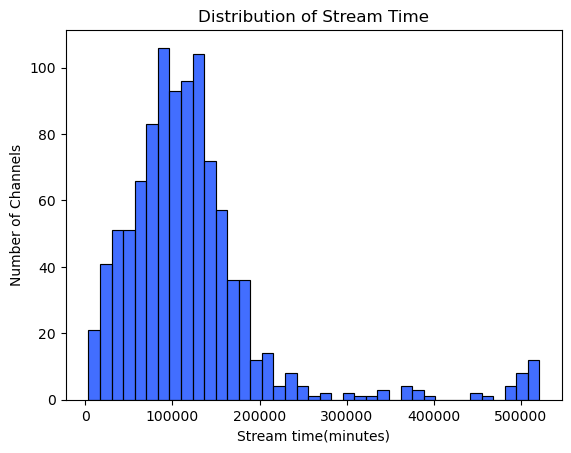

In [61]:
#Distributaion of Stream time (time Channel spent streaming)

sns.histplot(data=TwitchData, x="Stream time(minutes)")
plt.title("Distribution of Stream Time")
plt.ylabel("Number of Channels")

plt.show()

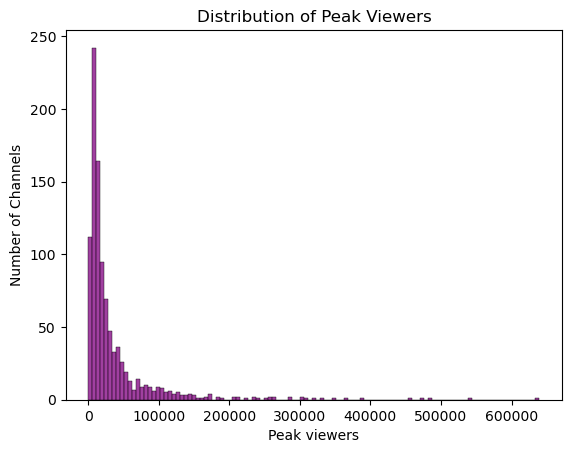

In [74]:
#Distributaion of Peak Viewers (maximum amount of viewers watching at the same time)

sns.histplot(data=TwitchData, x="Peak viewers",color="purple")
plt.title("Distribution of Peak Viewers")
plt.ylabel("Number of Channels")
plt.show()

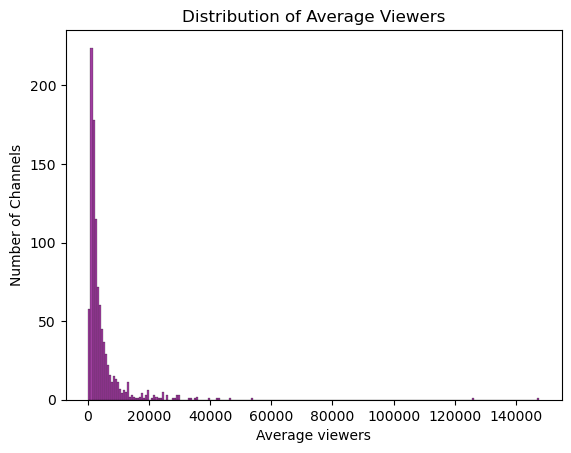

In [73]:
#Distributaion of Average Viewers (Average views per channel)

sns.histplot(data=TwitchData, x="Average viewers",color="purple")
plt.title("Distribution of Average Viewers")
plt.ylabel("Number of Channels")
plt.show()

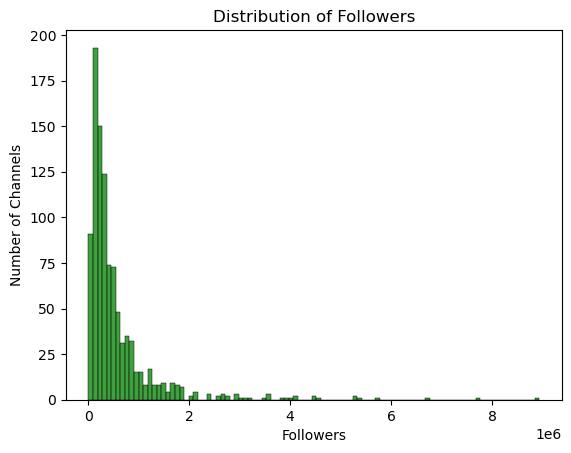

In [75]:
#Distributaion of Followers (Total followers)

sns.histplot(data=TwitchData, x="Followers",color="green")
plt.title("Distribution of Followers")
plt.ylabel("Number of Channels")
plt.show()

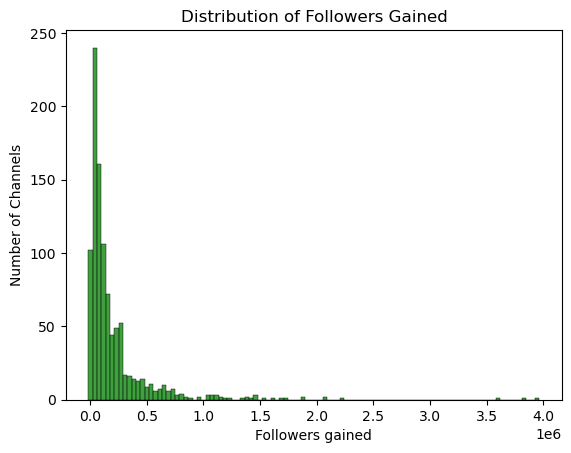

In [72]:
#Distributaion of Followers gained (followers gained during the period of the data collection)

sns.histplot(data=TwitchData, x="Followers gained", color='green')
plt.title("Distribution of Followers Gained")
plt.ylabel("Number of Channels")
plt.show()

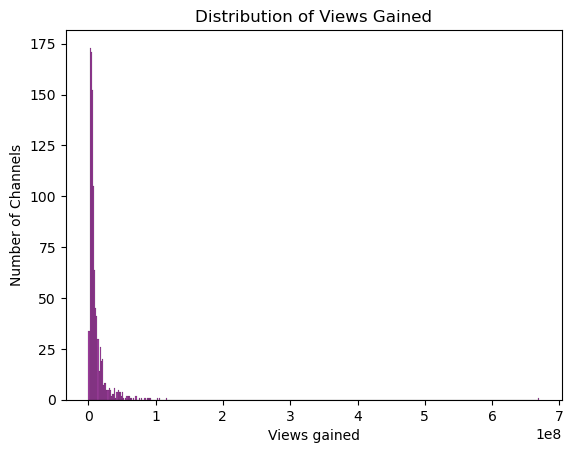

In [77]:
#Distributaion of Views gained (views gained (new users starting to watch the channel during the period of the data collection)

sns.histplot(data=TwitchData, x="Views gained", color='purple')
plt.title("Distribution of Views Gained")
plt.ylabel("Number of Channels")
plt.show()

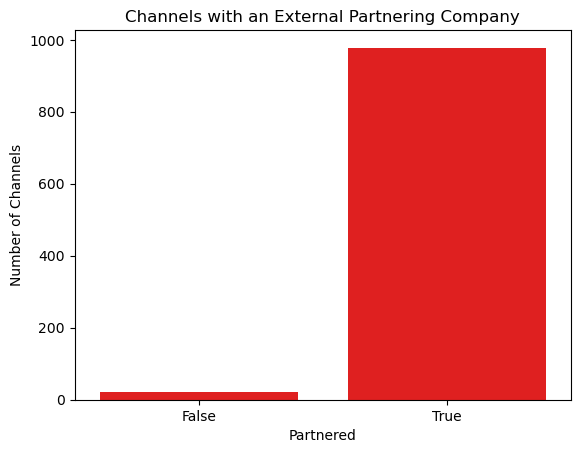

In [83]:
#Channels with an External Partnering Company sponsoring them.

sns.countplot(data=TwitchData, x="Partnered", color='red')
plt.title("Channels with an External Partnering Company")
plt.ylabel("Number of Channels")
plt.show()

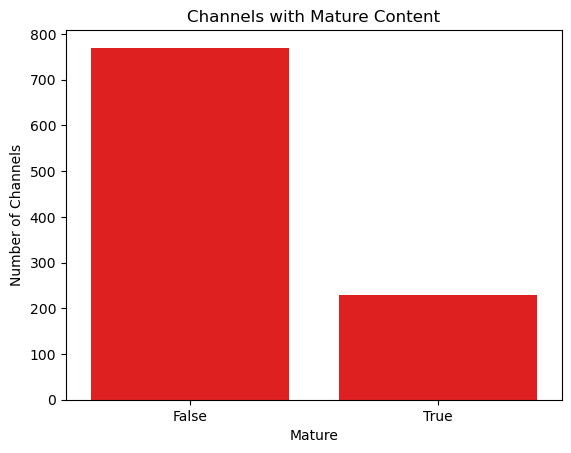

In [84]:
#Channels featuring content for an mature public.

sns.countplot(data=TwitchData, x="Mature", color='red')
plt.title("Channels with Mature Content")
plt.ylabel("Number of Channels")
plt.show()

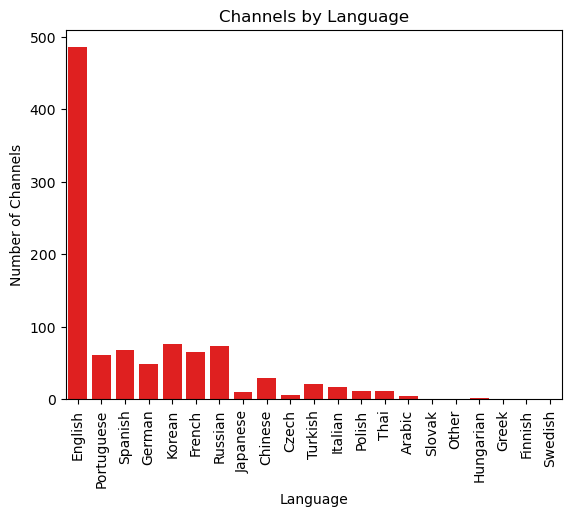

In [87]:
#Channels' speaking language.

sns.countplot(data=TwitchData, x="Language", color='red')
plt.title("Channels by Language")
plt.ylabel("Number of Channels")
plt.xticks(rotation=90) #names were rotated to be readable.
plt.show()

Once we illustrated the data, We put them all together in a box plot:

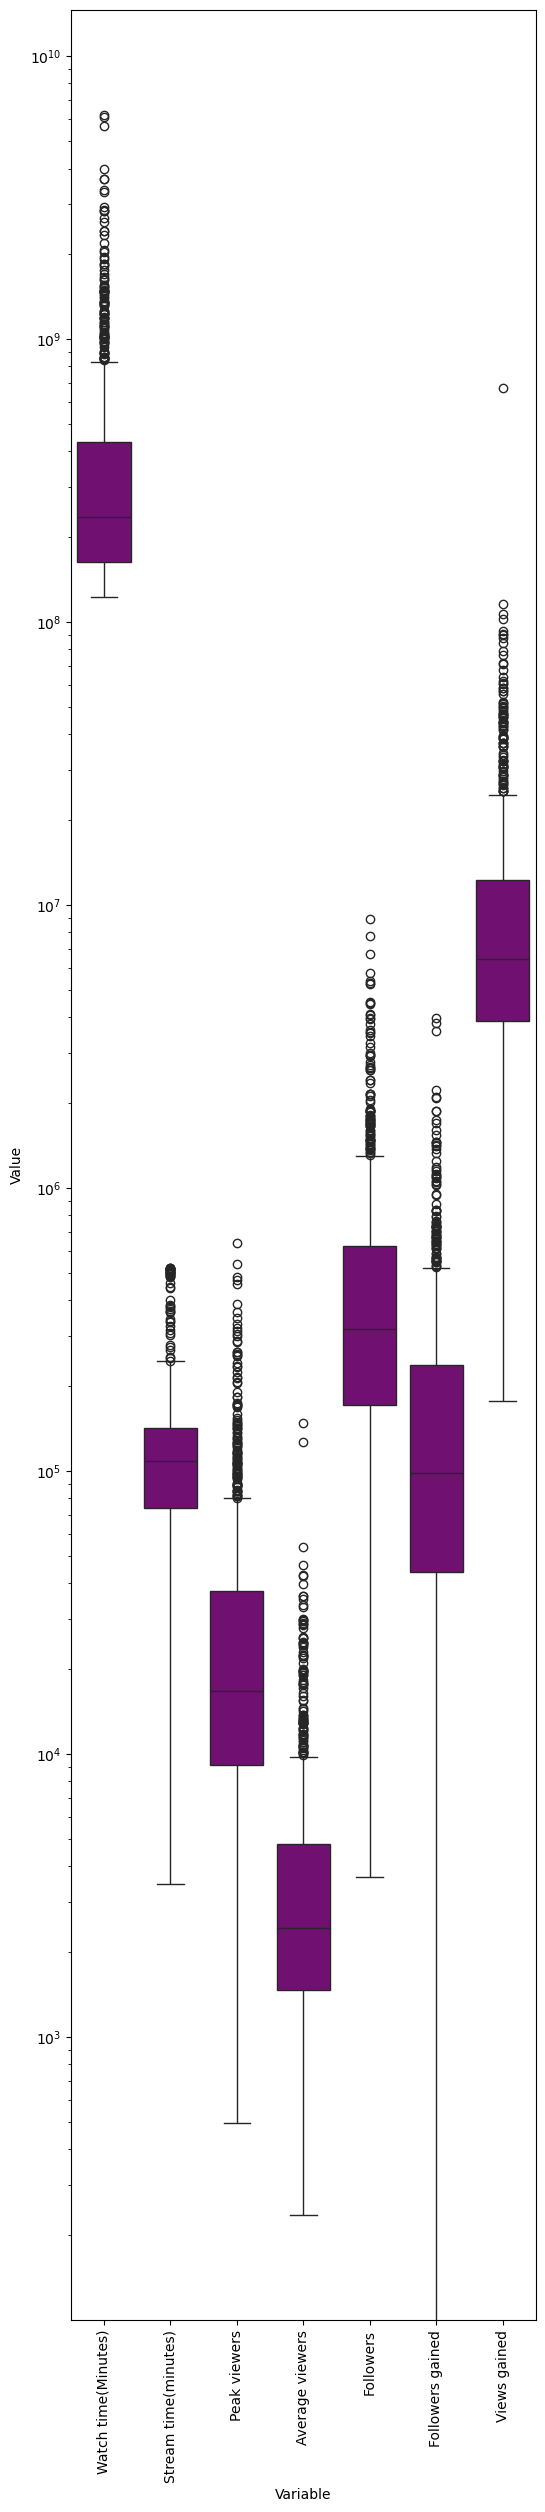

In [99]:
TwitchNum = TwitchData.select_dtypes(include="number")
TwitchMelt = TwitchNum.melt(var_name="Variable", value_name="Value") #data is melted to process it in the boxplot

#actual coding of the boxplot
plt.figure(figsize=(6,30)) #y-axis extended to make whiskers and other parts of the box data a little more noticeable
sns.boxplot(data=TwitchMelt, x="Variable", y="Value",color="purple")
plt.yscale("log") #scale set as log for better handling of the big numbers.
plt.xticks(rotation=90) #labels on x axis rotated for the sake of readability

plt.show()

Now Using the help of the .describe() function we can gather count, mean, standard deviation, minimum, maximum and percentages as shown below:

In [89]:
TwitchData.describe()

,Watch time(Minutes),Stream time(minutes),Peak viewers,Average viewers,Followers,Followers gained,Views gained
count,1.000000e+03,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03
mean,4.184279e+08,120515.160000,37065.051000,4781.040000,5.700541e+05,2.055185e+05,1.166817e+07
std,5.496355e+08,85376.201364,60314.307686,8453.684965,8.044134e+05,3.399137e+05,2.490572e+07
min,1.221928e+08,3465.000000,496.000000,235.000000,3.660000e+03,-1.577200e+04,1.757880e+05
25%,1.631899e+08,73758.750000,9113.750000,1457.750000,1.705462e+05,4.375825e+04,3.880602e+06
50%,2.349908e+08,108240.000000,16676.000000,2425.000000,3.180630e+05,9.835200e+04,6.456324e+06
75%,4.337399e+08,141843.750000,37569.750000,4786.250000,6.243322e+05,2.361308e+05,1.219676e+07
max,6.196162e+09,521445.000000,639375.000000,147643.000000,8.938903e+06,3.966525e+06,6.701375e+08


With the table and the graphs above we can conclude:
    *There is a high difference between means and medians of most variables, leading to a constantly right skewed graph for most of the variable, this means there is a mayority of channels
     with lower counts while the high count channels are really scarce.
    *Based on 75% adn maximum values we can see the presence of extreme outliers on this high extend, channels with a massive that may not really illustrate the usuall twitch traffic for the
     general streamer.
    *THe high STD numbers in variables like Watch time and Peak viewers tells about a high variability across the different channels.
    *There is a negative number in the minimum for followers gained suggest that many of the channels may have presented a loss of followers rather than a gain compared to the high level channels.